In [1]:
##import libraries##
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import healpy as hp

In [2]:
##Read the tif file##
FM = tiff.imread('/home/pratush/hires_fmscan.tif')
FM_array = np.array(FM)



In [3]:
# Define the spherical coordinates#
theta2 = np.linspace(np.radians(0), np.radians(180), num=FM_array.shape[0],endpoint=False)
phi2 = np.linspace(-np.radians(180), np.radians(180), num=FM_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
FMSCAN_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts2 = np.zeros(hp.nside2npix(nside), dtype=int)


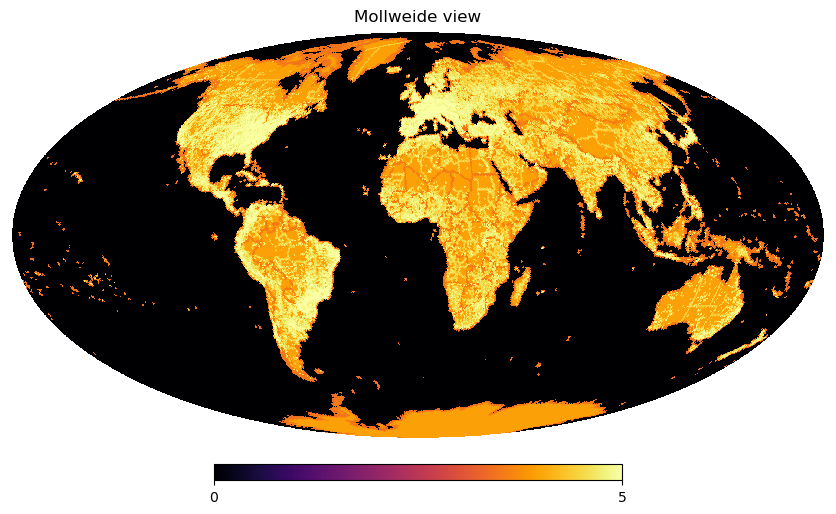

In [4]:
for i in range(len(theta2)):
    for j in range(len(phi2)):
        pixel2 = hp.ang2pix(nside, theta2[i], phi2[j])
        FMSCAN_map[pixel2] += FM_array[i, j]
        pixel_counts2[pixel2] += 1

# Average value of each pixel#
FMSCAN_map[pixel_counts2>0] /= pixel_counts2[pixel_counts2>0 ]

# healpix_map[healpix_map<2]=0
hp.mollview(FMSCAN_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()


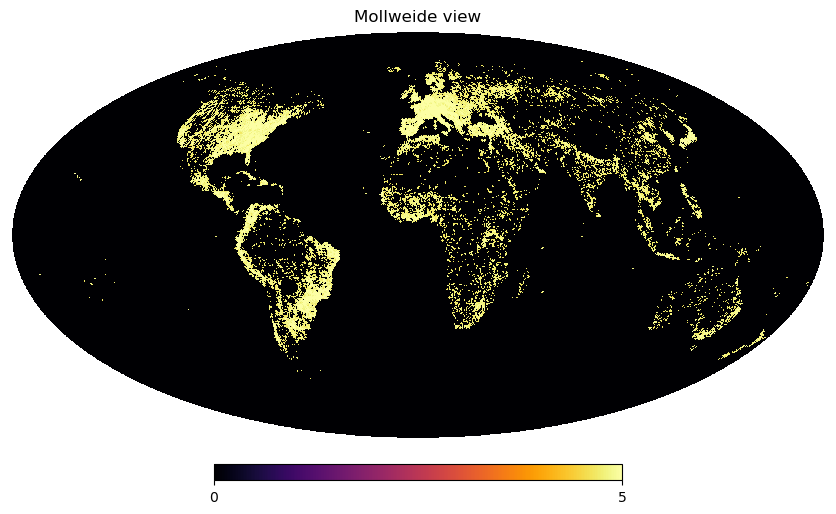

In [6]:
FMSCAN_map[FMSCAN_map<3]=0
hp.mollview(FMSCAN_map, cmap="inferno", xsize=3000, flip="geo", norm="hist")
plt.show()